In [1]:
from pathlib import Path
import sys

# Go from notebooks/ to project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\MedVision-AI


# MedVision-AI

# Notebook 08: Model Training Pipeline

---

## 🎯 Objectives

In this notebook, we train the EfficientNet-B0 model for pneumonia classification using the modular training engine developed in the `app/` package.

### Learning Outcomes

By the end of this notebook, you will be able to:

- Load the prepared DataLoaders
- Build the EfficientNet-B0 model
- Configure the loss function
- Configure the optimizer
- Configure the learning rate scheduler
- Train the model using reusable training modules
- Validate the model after each epoch
- Save the best-performing model
- Apply early stopping to prevent overfitting
- Store the complete training history

> Unlike traditional notebooks, this notebook does not implement training logic directly. Instead, it orchestrates reusable modules from the project package.

# Training Workflow

The complete training pipeline follows the sequence shown below.


Dataset
    │
    ▼
DataLoaders
    │
    ▼
EfficientNet-B0
    │
    ▼
Forward Pass
    │
    ▼
Loss Function
    │
    ▼
Backward Pass
    │
    ▼
Optimizer
    │
    ▼
Validation
    │
    ▼
Learning Rate Scheduler
    │
    ▼
Checkpoint Saving
    │
    ▼
Early Stopping
    │
    ▼
Training History


This notebook coordinates all these stages using reusable modules implemented in the `app/` package.

In [2]:
# ==========================================
# Standard Library Imports
# ==========================================

from pathlib import Path
import time

# ==========================================
# Third-Party Imports
# ==========================================

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [3]:
from app.models.efficientnet import build_efficientnet_b0

from app.training.trainer import train_one_epoch
from app.training.validator import validate_one_epoch

from app.training.history import TrainingHistory

from app.training.checkpoint import (
    save_checkpoint,
)

from app.training.early_stopping import (
    EarlyStopping,
)

c:\MedVision-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ==========================================
# Configuration
# ==========================================

from pathlib import Path

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_DIR = CHECKPOINT_DIR

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_CLASSES = 2

EPOCHS = 20

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

PATIENCE = 5

CHECKPOINT_DIR = Path("checkpoints")

CHECKPOINT_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = 224

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_model.pth"
)

# Loading the DataLoaders

The dataset has already been prepared in the previous notebooks.

During preprocessing we:

- Organized the Chest X-ray dataset into training, validation, and test sets.
- Applied data augmentation to the training set.
- Applied only normalization to the validation set.
- Created reusable PyTorch `Dataset` objects.
- Wrapped the datasets into `DataLoader` objects for efficient mini-batch loading.

In this notebook, we simply import the prepared DataLoaders. This separation follows the software engineering principle of **separation of concerns**, where data preparation and model training are implemented independently.

In [5]:
from app.preprocessing.dataset import get_dataloaders
from app.preprocessing.transforms import (
    train_transform,
    val_transform,
)

DATASET_PATH = Path(r"C:\MedVision-AI\dataset\chest_xray")

BATCH_SIZE = 32

train_loader, val_loader, test_loader = get_dataloaders(
    dataset_path=DATASET_PATH,
    train_transform=train_transform,
    val_transform=val_transform,
    batch_size=BATCH_SIZE,
)

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Testing batches    : {len(test_loader)}")

Training batches   : 163
Validation batches : 1
Testing batches    : 20


# Building the EfficientNet-B0 Model

The model architecture was implemented in `app/models/efficientnet.py`.

Rather than rebuilding the network in this notebook, we simply instantiate the reusable model.

This keeps the notebook focused on experiment orchestration while the model definition remains centralized in the application package.

In [6]:
# ==========================================
# Build Model
# ==========================================

model = build_efficientnet_b0(
    num_classes=NUM_CLASSES,
    pretrained=True,
)

model = model.to(DEVICE)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [7]:
# ==========================================
# Loss Function
# ==========================================

criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [8]:
# ==========================================
# Optimizer
# ==========================================

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [9]:
# ==========================================
# Learning Rate Scheduler
# ==========================================

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2,
)

print(scheduler)

In [10]:
# ==========================================
# Training Utilities
# ==========================================

history = TrainingHistory()

early_stopping = EarlyStopping(
    patience=PATIENCE,
)

print("Training utilities initialized.")

Training utilities initialized.


In [11]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [12]:
# ==========================================
# Training Loop
# ==========================================

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    print("=" * 70)
    print(f"Epoch [{epoch + 1}/{EPOCHS}]")
    print("=" * 70)

    # -----------------------------
    # Training
    # -----------------------------

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
    )

    # -----------------------------
    # Validation
    # -----------------------------

    val_loss, val_accuracy = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=DEVICE,
    )

    # -----------------------------
    # Scheduler
    # -----------------------------

    scheduler.step(val_loss)

    # -----------------------------
    # Store History
    # -----------------------------

    history.update(
        train_loss=train_loss,
        val_loss=val_loss,
        train_accuracy=train_accuracy,
        val_accuracy=val_accuracy,
    )

    # -----------------------------
    # Print Epoch Summary
    # -----------------------------

    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Train Acc : {train_accuracy:.2f}%"
    )

    print(
        f"Val Loss   : {val_loss:.4f} | "
        f"Val Acc   : {val_accuracy:.2f}%"
    )

    # -----------------------------
    # Save Best Model
    # -----------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        save_checkpoint(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch + 1,
            val_loss=val_loss,
            filepath=MODEL_SAVE_DIR / "best_model.pth",
        )

        print("Best model saved.")

    # -----------------------------
    # Early Stopping
    # -----------------------------

    if early_stopping(val_loss):

        print("\nEarly stopping triggered.")
        break

Epoch [1/20]


Train Loss : 0.2847 | Train Acc : 89.13%
Val Loss   : 0.3717 | Val Acc   : 81.25%
Best model saved.
Epoch [2/20]


Train Loss : 0.1812 | Train Acc : 93.02%
Val Loss   : 0.4700 | Val Acc   : 81.25%
Epoch [3/20]


Train Loss : 0.1600 | Train Acc : 93.87%
Val Loss   : 0.2931 | Val Acc   : 87.50%
Best model saved.
Epoch [4/20]


Train Loss : 0.1541 | Train Acc : 94.40%
Val Loss   : 0.2841 | Val Acc   : 87.50%
Best model saved.
Epoch [5/20]


...

Train Loss : 0.1417 | Train Acc : 94.52%
Val Loss   : 0.3279 | Val Acc   : 87.50%
Epoch [7/20]


Train Loss : 0.1376 | Train Acc : 94.84%
Val Loss   : 0.2939 | Val Acc   : 87.50%
Epoch [8/20]


Train Loss : 0.1485 | Train Acc : 93.92%
Val Loss   : 0.2884 | Val Acc   : 87.50%
Epoch [9/20]


Train Loss : 0.1318 | Train Acc : 95.11%
Val Loss   : 0.2630 | Val Acc   : 87.50%
Epoch [10/20]


Train Loss : 0.1459 | Train Acc : 94.48%
Val Loss   : 0.3410 | Val Acc   : 87.50%

Early stopping triggered.


## Save Training History

The training metrics collected during each epoch are saved for future
analysis and visualization. This enables reproducibility and allows
comparison between different training experiments.

In [13]:
# ==========================================
# Save Training History
# ==========================================

history.save(
    MODEL_SAVE_DIR / "training_history.json"
)

print("Training history saved successfully.")

Training history saved successfully.


## Training History

Display the recorded training and validation metrics for each epoch.

In [14]:
# ==========================================
# Display Training History
# ==========================================

history_df = history.to_dataframe()

history_df

,train_loss,val_loss,train_accuracy,val_accuracy
0,0.284681,0.371688,89.129601,81.25
1,0.181166,0.470000,93.021472,81.25
2,0.160026,0.293063,93.865031,87.50
3,0.154126,0.284144,94.401840,87.50
4,0.142533,0.241594,94.727761,87.50
5,0.141687,0.327924,94.516871,87.50
6,0.137552,0.293904,94.842791,87.50
7,0.148451,0.288429,93.922546,87.50
8,0.131785,0.263025,95.111196,87.50
9,0.145915,0.341027,94.478528,87.50


## Learning Curves

Visualize the training and validation performance across epochs to
understand convergence and detect overfitting.

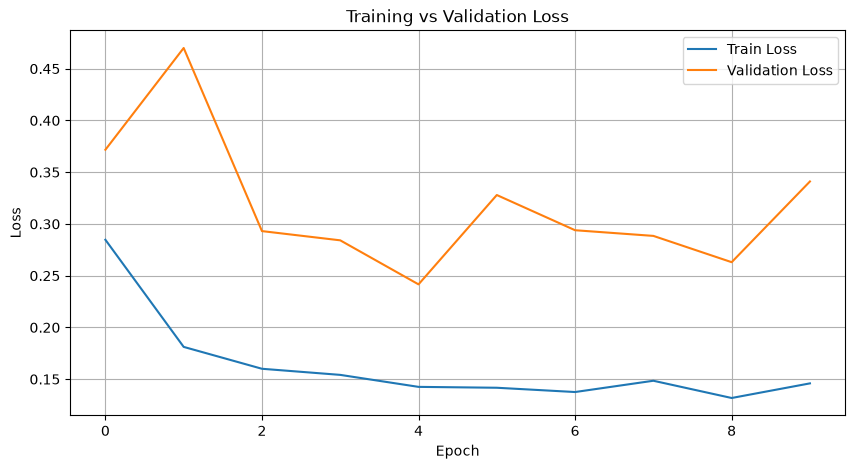

In [15]:
import matplotlib.pyplot as plt

history_df = history.to_dataframe()

plt.figure(figsize=(10,5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

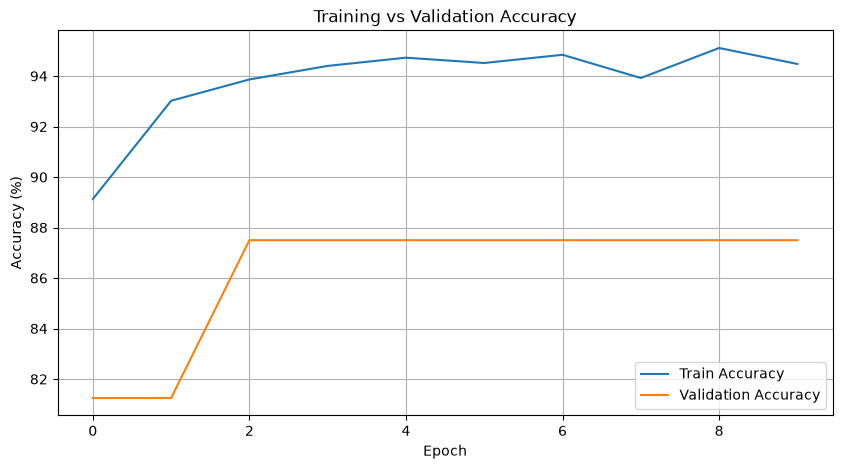

In [16]:
plt.figure(figsize=(10,5))
plt.plot(history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Training Summary

The EfficientNet-B0 model was successfully trained using the Chest X-ray
dataset. The best-performing model checkpoint was automatically saved
based on the lowest validation loss.

The saved checkpoint will be used in the next notebook for model
evaluation on the unseen test dataset.

In [17]:
# ==========================================
# Training Summary
# ==========================================

print("=" * 60)
print("Training Completed Successfully")
print("=" * 60)

print(f"Epochs Completed      : {len(history_df)}")
print(f"Best Validation Loss  : {best_val_loss:.4f}")
print(f"Best Validation Acc   : {history_df['val_accuracy'].max():.2f}%")
print(f"Checkpoint Saved At   : {MODEL_SAVE_DIR / 'best_model.pth'}")
print(f"History Saved At      : {MODEL_SAVE_DIR / 'training_history.json'}")

Training Completed Successfully
Epochs Completed      : 10
Best Validation Loss  : 0.2416
Best Validation Acc   : 87.50%
Checkpoint Saved At   : ..\checkpoints\best_model.pth
History Saved At      : ..\checkpoints\training_history.json


# Conclusion

In this notebook, we successfully trained an EfficientNet-B0 model for
binary chest X-ray classification (Normal vs Pneumonia).

The training pipeline included:

- EfficientNet-B0 with ImageNet pretrained weights
- AdamW optimizer
- CrossEntropyLoss
- Learning rate scheduling
- Early stopping
- Automatic checkpoint saving
- Training history recording

The best-performing model has been saved and is ready for evaluation.

**Next Notebook:** 09_Model_Evaluation.ipynb